### Data loading and set up

In [ ]:
from pathlib import Path
from cortech import Cortex, Surface
import nibabel as nib
import pyvista as pv
import numpy as np
from nibabel.freesurfer import read_morph_data
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

# Base directories
subjects_dir = Path("/home/oana/UDel/fsruns")
mre_dir = Path("/home/oana/MRE_analysis") 
group_dir = Path("/home/oana/MRE_group_results")


# Fetch fsaverage
fsavg = Cortex.from_freesurfer_subject_dir("fsaverage", registration="sphere.reg")

# Read in the subjects and prepare
print("Reading in the data")
subids=["0001","0002","0003","0004","0005","0006","0007","0008","0009","0010","0011"]
cortices = {}
for sub in subids:
    subject = subjects_dir / sub
    mre_dir = Path("/home/oana/MRE_analysis") / sub
    cortices[sub] = Cortex.from_freesurfer_subject_dir(subject, pial="pial.T1", registration="sphere.reg")
    for hemi, hemi_fsav in zip(cortices[sub].hemispheres, fsavg.hemispheres):
        # Add spherical registration to fsav
        hemi.registration.project(hemi_fsav.registration)
        hemi.white.smooth_taubin(n_iter=5, inplace=True)
        hemi.pial.smooth_taubin(n_iter=5, inplace=True)

# Fit the layers
print("Fitting the middle layer")
mid_layers_subjects = {}
for sub in subids:
    mid_layers_subjects[sub] = {
        "lh": cortices[sub].lh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True),
        "rh": cortices[sub].rh.estimate_layers(method="equivolume", frac=0.5, curv_kwargs={'smooth_iter': 10}, return_surface=True)
    }

# Okay, interpolate the data to the middle surface and then map to fsavg
scan_names = {
    "stiff":  "MRE_stiffness_in_T1_space.nii.gz",
    "real": "MRE_real_in_T1_space.nii.gz",
    "imag": "MRE_imag_in_T1_space.nii.gz",
    "myelin": "Myelin.nii.gz",
}

print("Interpolating data to fsaverage")
subject_data_on_fsaverage = {}
for sub in subids:
    cortex = cortices[sub]
    mid_layer = mid_layers_subjects[sub]
    fsavg_data = {}
    mre_dir = Path("/home/oana/MRE_analysis") / sub
    for scan in scan_names.keys():
        im_tmp = nib.load(mre_dir / f"{scan_names[scan]}")
        hemi_data = {}
        for hemi in cortex.hemispheres:
            # Interpolate
            hemi_data_tmp = mid_layer[hemi.name].interpolate_to_nodes(im_tmp.get_fdata(), im_tmp.affine)
            # Map
            hemi_data[hemi.name] = hemi.registration.resample(hemi_data_tmp)
        fsavg_data[scan] = hemi_data

    geometric = {
        "curvature": "curv",
        "thickness": "thickness",
        "sulcal_depth": "sulc",
    }

    for geom_name, fs_name in geometric.items():

        hemi_data = {}

        for hemi in cortex.hemispheres:

            surf_file = subjects_dir / sub / "surf" / f"{hemi.name}.{fs_name}"
            data = read_morph_data(surf_file)

            # Directly resample 
            hemi_data[hemi.name] = hemi.registration.resample(data)

        fsavg_data[geom_name] = hemi_data
    subject_data_on_fsaverage[sub] = fsavg_data


# Compute the average over subjects for each scan along with the standard deviation
average = {}
sd = {}

for scan in scan_names.keys():
    hemi_mean = {}
    hemi_sd = {}
    for hemi in ["lh", "rh"]:
        #data_tmp = np.zeros((fsavg.lh.white.n_vertices, len(subids)))
        n_vertices = subject_data_on_fsaverage[subids[0]][scan][hemi].shape[0]
        data_tmp = np.zeros((n_vertices, len(subids)))
        for s, sub in enumerate(subids):
            data_tmp[:, s] = subject_data_on_fsaverage[sub][scan][hemi]
        hemi_mean[hemi] = data_tmp.mean(axis=1)
        hemi_sd[hemi] = data_tmp.std(axis=1)
        # Save for later use
        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_mean[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.{scan}.mid.layer.average.mgh")
        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_sd[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.fsaverage.{scan}.mid.layer.sd.mgh")
    average[scan] = hemi_mean
    sd[scan] = hemi_sd

geo_average = {}
geo_sd = {}

for geom in geometric.keys():
    hemi_mean = {}
    hemi_sd = {}

    for hemi in ["lh", "rh"]:
        n_vertices = subject_data_on_fsaverage[subids[0]][geom][hemi].shape[0]
        data_tmp = np.zeros((n_vertices, len(subids)))

        for s, sub in enumerate(subids):
            data_tmp[:, s] = subject_data_on_fsaverage[sub][geom][hemi]

        hemi_mean[hemi] = data_tmp.mean(axis=1)
        hemi_sd[hemi] = data_tmp.std(axis=1)
        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_mean[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.{geom}.mid.layer.average.mgh")

        overlay_tmp = nib.freesurfer.mghformat.MGHImage(hemi_sd[hemi].astype("float32"), np.eye(4))
        nib.save(overlay_tmp, group_dir / f"{hemi}.{geom}.mid.layer.sd.mgh")

    geo_average[geom] = hemi_mean
    geo_sd[geom] = hemi_sd



Reading in the data
Fitting the middle layer
Interpolating data to fsaverage


In [ ]:
from pathlib import Path
from cortech import Cortex, Surface
import nibabel as nib
import pyvista as pv
import numpy as np
from nibabel.freesurfer import read_morph_data
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

### Visualize group maps on fsaverage surface

In [2]:
# Visualize on the fsaverage using pyvista. 

sub_plotter = FsPlotter(subject="fsaverage", surface='inflated')
sub_plotter.add_curvature()
sub_plotter.add_standard_morphological_data()
sub_plotter.add_annotation('aparc')
for scan in average.keys():
    sub_plotter.add_overlay(average[scan], name=f"{scan}_average")
    sub_plotter.add_overlay(sd[scan], name=f"{scan}_sd")
for geom in geo_average.keys():
    sub_plotter.add_overlay(geo_average[geom], name=f"{geom}_average")
    sub_plotter.add_overlay(geo_sd[geom], name=f"{geom}_sd")
iplotter = InteractivePlotter(sub_plotter)
widget = iplotter.get_widget()
widget

Widget(value='<iframe src="http://localhost:36793/index.html?ui=P_0x7f8ec2834c50_0&reconnect=auto" class="pyvi…

### Compare mechanical and geometric properties across parcels 

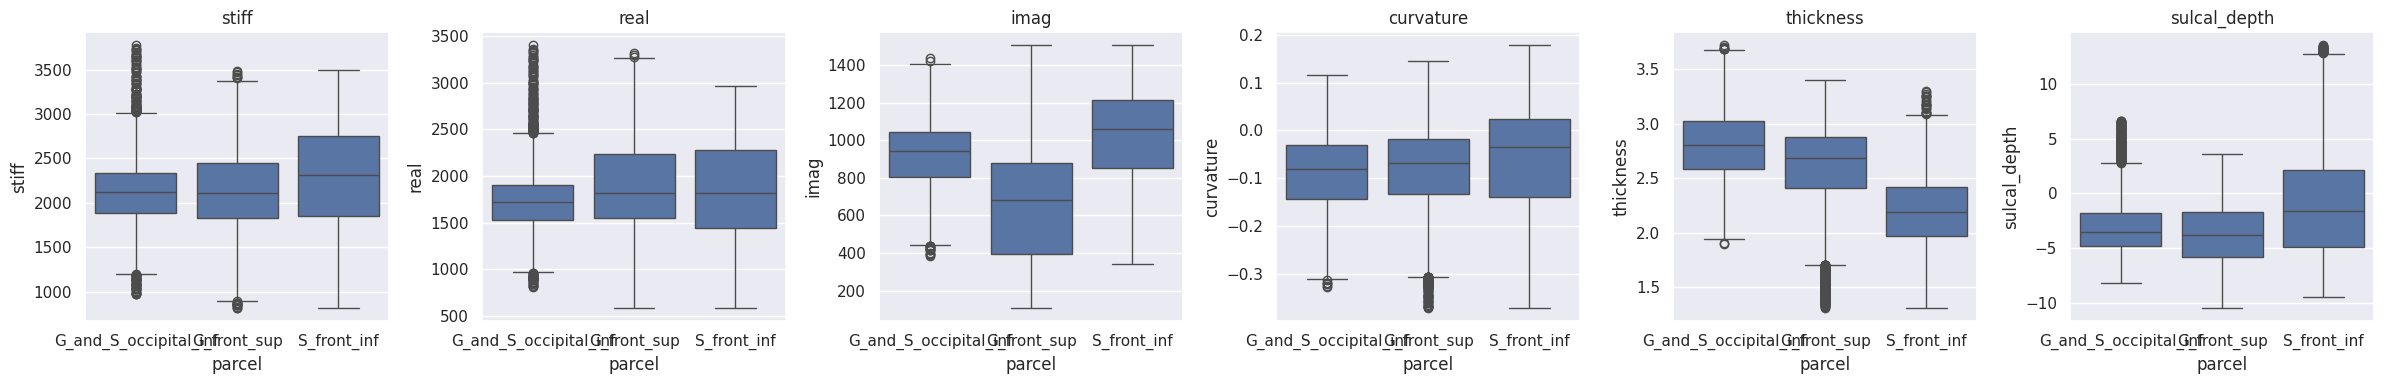

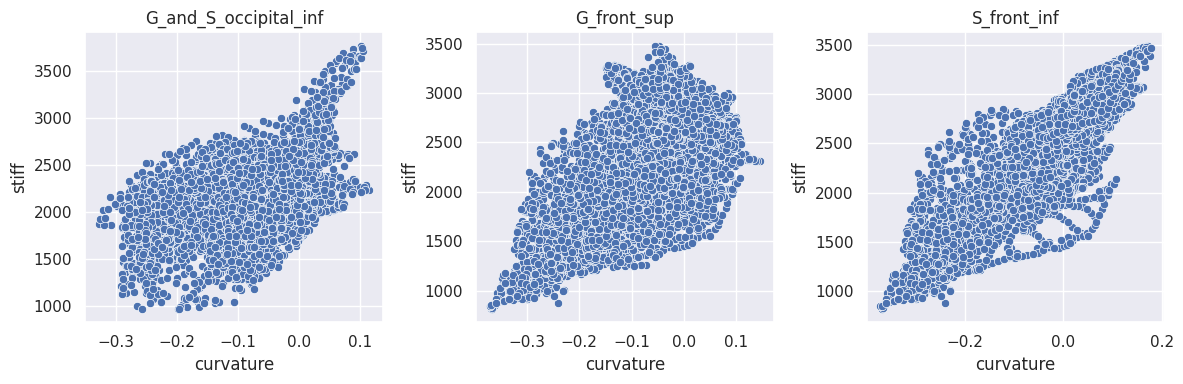

In [ ]:
from cortech import Cortex, Surface, freesurfer
import nibabel as nib
import pyvista as pv
import numpy as np
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

# Fetch fsaverage
fsavg = Cortex.from_freesurfer_subject_dir("fsaverage", registration="sphere.reg")

# Read in the annotation
labels = {
    'lh': nib.freesurfer.io.read_annot(freesurfer.HOME / 'subjects' / 'fsaverage' / 'label' / 'lh.aparc.a2009s.annot'),
    'rh': nib.freesurfer.io.read_annot(freesurfer.HOME / 'subjects' / 'fsaverage' / 'label' / 'rh.aparc.a2009s.annot'),
}


all_scans = [
    "stiff",
    "real",
    "imag",
    "curvature",
    "thickness",
    "sulcal_depth",
]

group_dir = Path("/home/oana/MRE_group_results")

# Read in the mid layer values we saved to disk
mid_layer_values = {}
for scan in all_scans:
    hemi_data = {}
    for hemi in ['lh', 'rh']:
        hemi_data[hemi] = nib.load(group_dir / f"{hemi}.{scan}.mid.layer.average.mgh").get_fdata()
    mid_layer_values[scan] = hemi_data


# Let's plot the data in differentregions
parcel_labels = {'G_and_S_occipital_inf': {'lh': labels['lh'][2].index(b'G_precentral'), 'rh': labels['rh'][2].index(b'G_and_S_occipital_inf')},
                 'G_front_sup': {'lh': labels['lh'][2].index(b'G_postcentral'), 'rh': labels['rh'][2].index(b'G_front_sup')},
                 'S_front_inf': {'lh': labels['lh'][2].index(b'G_postcentral'), 'rh': labels['rh'][2].index(b'S_front_inf')}}

# Grab the values in those areas combining lh and rh
parcel_data = {}
for scan in mid_layer_values.keys():
    mid_layer = mid_layer_values[scan]
    area_data = {}

    for area in parcel_labels.keys():
        area_labels = parcel_labels[area]
        data_tmp = []

        for hemi in area_labels.keys():
            data_tmp += mid_layer[hemi][labels[hemi][0] == area_labels[hemi]].squeeze().tolist()
        area_data[area] = data_tmp
    parcel_data[scan] = area_data

# Plot the values as boxplots for the different regions and scans
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
sns.set_theme(style="darkgrid")


fig, axs = plt.subplots(1, len(all_scans), figsize=(24, 4))

for i, scan in enumerate(parcel_data.keys()):
    dict_tmp = {'parcel': [], scan: []}

    for area in parcel_data[scan].keys():
        values = parcel_data[scan][area]
        dict_tmp[scan] += values
        dict_tmp['parcel'] += [area] * len(values)

    df_tmp = pd.DataFrame(dict_tmp)
    sns.boxplot(x='parcel', y=scan, data=df_tmp, ax=axs[i])
    axs[i].set_title(scan)

plt.tight_layout()
plt.show()


# Scatter plot
fig, axs = plt.subplots(1, len(parcel_labels), figsize=(12, 4))

for i, area in enumerate(parcel_labels.keys()):
    df_tmp = pd.DataFrame({
        "stiff": parcel_data["stiff"][area],
        "curvature": parcel_data["curvature"][area]
    })

    sns.scatterplot(data=df_tmp, x="curvature", y="stiff", ax=axs[i])
    axs[i].set_title(area)

plt.tight_layout()
plt.show()

plt.show()

### Vertex-wise correlations

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import itertools

# Parameters available
mre_params = ["stiff", "real", "imag"]
geo_params = ["curvature", "thickness", "sulcal_depth"]

vertexwise_results = {}

for hemi in ["lh", "rh"]:

    print(f"\nRunning vertex-wise stats for {hemi}")

    n_vertices = subject_data_on_fsaverage[subids[0]]["stiff"][hemi].shape[0]

    # Pre-build matrices for all parameters
    matrices = {}

    for param in mre_params + geo_params:
        mat = np.zeros((len(subids), n_vertices))
        for s, sub in enumerate(subids):
            mat[s, :] = subject_data_on_fsaverage[sub][param][hemi]
        matrices[param] = mat

    vertexwise_results[hemi] = {}

    # Loop over parameter pairs (MRE vs Geometry)
    for p1 in mre_params:
        for p2 in geo_params:

            print(f"  {p1} vs {p2}")

            rho = np.zeros(n_vertices)
            pvals = np.zeros(n_vertices)

            for v in range(n_vertices):
                r, p = spearmanr(
                    matrices[p1][:, v],
                    matrices[p2][:, v]
                )
                rho[v] = r
                pvals[v] = p

            # FDR correction
            _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")

            rho_corrected = rho.copy()
            rho_corrected[pvals_fdr > 0.05] = 0

            vertexwise_results[hemi][f"{p1}_vs_{p2}"] = {
                "rho": rho,
                "pvals": pvals,
                "pvals_fdr": pvals_fdr,
                "rho_fdr": rho_corrected
            }


Running vertex-wise stats for lh
  stiff vs curvature
  stiff vs thickness


/tmp/ipykernel_524539/4131003686.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(


  stiff vs sulcal_depth
  real vs curvature
  real vs thickness
  real vs sulcal_depth
  imag vs curvature
  imag vs thickness
  imag vs sulcal_depth

Running vertex-wise stats for rh
  stiff vs curvature
  stiff vs thickness
  stiff vs sulcal_depth
  real vs curvature
  real vs thickness
  real vs sulcal_depth
  imag vs curvature
  imag vs thickness
  imag vs sulcal_depth


In [ ]:
for hemi in ["lh", "rh"]:
    print(f"\nHemisphere: {hemi}")
    for key in vertexwise_results[hemi].keys():
        n_sig = np.sum(vertexwise_results[hemi][key]["pvals_fdr"] < 0.05)
        print(f"{key}: {n_sig} significant vertices")


Hemisphere: lh
stiff_vs_curvature: 2695 significant vertices
stiff_vs_thickness: 0 significant vertices
stiff_vs_sulcal_depth: 3695 significant vertices
real_vs_curvature: 2036 significant vertices
real_vs_thickness: 0 significant vertices
real_vs_sulcal_depth: 2153 significant vertices
imag_vs_curvature: 1573 significant vertices
imag_vs_thickness: 0 significant vertices
imag_vs_sulcal_depth: 4541 significant vertices

Hemisphere: rh
stiff_vs_curvature: 2025 significant vertices
stiff_vs_thickness: 0 significant vertices
stiff_vs_sulcal_depth: 3507 significant vertices
real_vs_curvature: 1563 significant vertices
real_vs_thickness: 0 significant vertices
real_vs_sulcal_depth: 2790 significant vertices
imag_vs_curvature: 836 significant vertices
imag_vs_thickness: 0 significant vertices
imag_vs_sulcal_depth: 2878 significant vertices


In [ ]:
sub_plotter = FsPlotter(subject="fsaverage", surface='inflated')
sub_plotter.add_curvature()

sub_plotter.add_overlay(
    {
        "lh": vertexwise_results["lh"]["stiff_vs_curvature"]["rho_fdr"],
        "rh": vertexwise_results["rh"]["stiff_vs_curvature"]["rho_fdr"],
    },
    name="stiff_vs_curvature_rho_fdr"
)

iplotter = InteractivePlotter(sub_plotter)
widget = iplotter.get_widget()
widget

Widget(value='<iframe src="http://localhost:38315/index.html?ui=P_0x7f5d95cdbd10_0&reconnect=auto" class="pyvi…

Exception raised
KeyError('Data named "stiff_vs_curvature_rho_fdr" does not exist in this dataset.')
Traceback (most recent call last):
  File "/home/oana/.pyenv/versions/3.11.8/lib/python3.11/site-packages/wslink/protocol.py", line 324, in onCompleteMessage
    results = func(*args, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^
  File "/home/oana/.pyenv/versions/3.11.8/lib/python3.11/site-packages/trame_server/protocol.py", line 236, in update_state
    with self.server.state:
  File "/home/oana/.pyenv/versions/3.11.8/lib/python3.11/site-packages/trame_server/state.py", line 354, in __exit__
    self.flush()
  File "/home/oana/.pyenv/versions/3.11.8/lib/python3.11/site-packages/trame_server/state.py", line 339, in flush
    keys |= self._flush_pending_keys()
            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/oana/.pyenv/versions/3.11.8/lib/python3.11/site-packages/trame_server/state.py", line 319, in _flush_pending_keys
    coroutine = callback(**reverse_translated_state)
          

In [ ]:
from cortech.visualization import FsPlotter
from cortech.interactive_visualization import InteractivePlotter

# Initialize the plotter
sub_plotte = FsPlotter(subject="fsaverage", surface='inflated')
sub_plotte.add_curvature()
sub_plotte.add_standard_morphological_data()
sub_plotte.add_annotation('aparc')

# All MRE and geometric pairs
mre_params = ["stiff", "real", "imag"]
geom_params = ["curvature", "thickness", "sulcal_depth"]

for mre in mre_params:
    for geom in geom_params:
        overlay_name = f"{mre}_vs_{geom}"
        print(f"Adding overlay: {overlay_name}")
        sub_plotte.add_overlay(
            {
                "lh": vertexwise_results["lh"][overlay_name]["rho_fdr"],
                "rh": vertexwise_results["rh"][overlay_name]["rho_fdr"],
            },
            name=overlay_name
        )

# Create interactive viewer
iplotter = InteractivePlotter(sub_plotte)
widget = iplotter.get_widget()
widget

Adding overlay: stiff_vs_curvature
Adding overlay: stiff_vs_thickness
Adding overlay: stiff_vs_sulcal_depth
Adding overlay: real_vs_curvature
Adding overlay: real_vs_thickness
Adding overlay: real_vs_sulcal_depth
Adding overlay: imag_vs_curvature
Adding overlay: imag_vs_thickness
Adding overlay: imag_vs_sulcal_depth


Widget(value='<iframe src="http://localhost:38315/index.html?ui=P_0x7f5ce08d5910_2&reconnect=auto" class="pyvi…

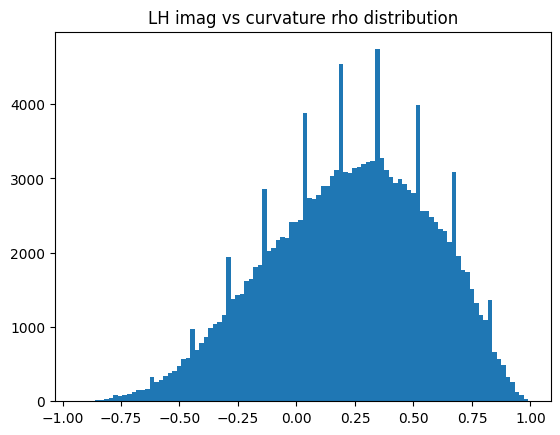

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    vertexwise_results["lh"]["imag_vs_curvature"]["rho"],
    bins=100
)
plt.title("LH imag vs curvature rho distribution")
plt.show()

In [ ]:
for hemi in ["lh", "rh"]:
    print(f"\nHemisphere: {hemi}")
    for key in vertexwise_results[hemi].keys():
        mean_abs_rho = np.nanmean(
            np.abs(vertexwise_results[hemi][key]["rho"])
        )
        print(f"{key}: mean |rho| = {mean_abs_rho:.3f}")


Hemisphere: lh
stiff_vs_curvature: mean |rho| = 0.363
stiff_vs_thickness: mean |rho| = 0.301
stiff_vs_sulcal_depth: mean |rho| = 0.368
real_vs_curvature: mean |rho| = 0.355
real_vs_thickness: mean |rho| = 0.300
real_vs_sulcal_depth: mean |rho| = 0.362
imag_vs_curvature: mean |rho| = 0.343
imag_vs_thickness: mean |rho| = 0.298
imag_vs_sulcal_depth: mean |rho| = 0.356

Hemisphere: rh
stiff_vs_curvature: mean |rho| = 0.360
stiff_vs_thickness: mean |rho| = 0.293
stiff_vs_sulcal_depth: mean |rho| = 0.360
real_vs_curvature: mean |rho| = 0.353
real_vs_thickness: mean |rho| = 0.291
real_vs_sulcal_depth: mean |rho| = 0.358
imag_vs_curvature: mean |rho| = 0.347
imag_vs_thickness: mean |rho| = 0.298
imag_vs_sulcal_depth: mean |rho| = 0.355


In [ ]:
def show_overlay(overlay_lh, overlay_rh, name):
    from cortech.visualization import FsPlotter
    from cortech.interactive_visualization import InteractivePlotter
    
    sub_plotter = FsPlotter(subject="fsaverage", surface='inflated')
    sub_plotter.add_curvature()
    
    sub_plotter.add_overlay(
        {"lh": overlay_lh, "rh": overlay_rh},
        name=name
    )

    iplotter = InteractivePlotter(sub_plotter)
    return iplotter.get_widget()

def show_pair(mre, geom):
    key = f"{mre}_vs_{geom}"
    return show_overlay(
        vertexwise_results["lh"][key]["rho_fdr"],
        vertexwise_results["rh"][key]["rho_fdr"],
        key
    )

In [ ]:
show_pair("stiff", "curvature")
show_pair("real", "sulcal_depth")
show_pair("imag", "curvature")

Widget(value='<iframe src="http://localhost:38315/index.html?ui=P_0x7f5ce0367ed0_7&reconnect=auto" class="pyvi…


Subject-level means:
            stiff         real         imag  curvature  thickness  \
0001  2768.177523  2340.740125  1062.000957  -0.017975   2.423778   
0002  2721.136673  2308.757541  1039.058703  -0.024162   2.403812   
0003  2654.697284  2227.601337  1035.106553  -0.021165   2.245355   
0004  2688.000083  2294.827901  1007.499542  -0.022302   2.397414   
0005  2599.764134  2187.129556  1000.471555  -0.024655   2.392833   
0006  2573.328270  2200.346273   956.302620  -0.022338   2.439019   
0007  2815.625774  2429.343037  1029.711313  -0.022550   2.476041   
0008  2697.110906  2284.076214  1036.856354  -0.021765   2.357383   
0009  2748.543712  2344.521793  1064.725108  -0.019682   2.307233   
0010  2640.094469  2243.685235  1006.426434  -0.023852   2.203269   
0011  2391.102557  2024.928052   916.173254  -0.025848   2.226115   

      sulcal_depth  
0001      0.421084  
0002      0.366843  
0003      0.358969  
0004      0.394941  
0005      0.358315  
0006      0.434863  
00

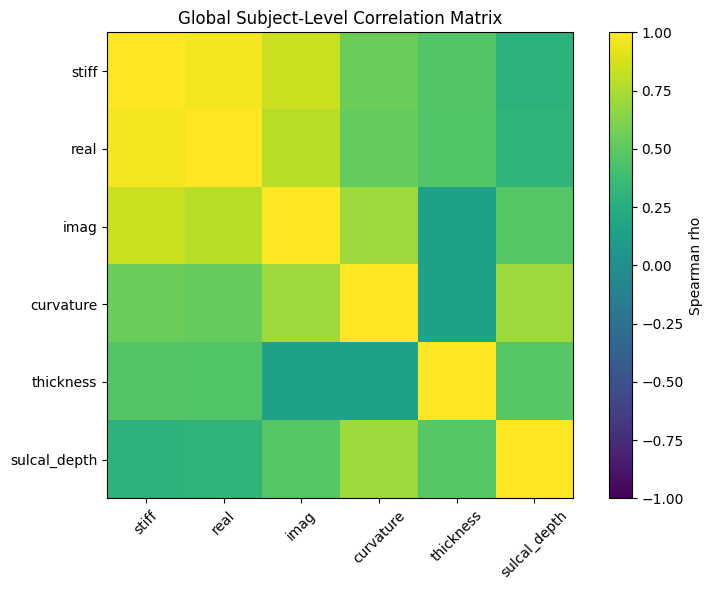

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Parameters to include
parameters = [
    "stiff",
    "real",
    "imag",
    "curvature",
    "thickness",
    "sulcal_depth",
]

# Store subject-level global means
subject_means = {param: [] for param in parameters}

for sub in subids:
    for param in parameters:

        # average across both hemispheres
        lh_mean = subject_data_on_fsaverage[sub][param]["lh"].mean()
        rh_mean = subject_data_on_fsaverage[sub][param]["rh"].mean()

        subject_means[param].append((lh_mean + rh_mean) / 2)

# Convert to DataFrame
df = pd.DataFrame(subject_means, index=subids)

print("\nSubject-level means:")
print(df)

# Compute Spearman correlation matrix
corr_matrix = df.corr(method="spearman")

print("\nSpearman correlation matrix:")
print(corr_matrix)

# Plot correlation matrix
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, vmin=-1, vmax=1)
plt.colorbar(label="Spearman rho")
plt.xticks(range(len(parameters)), parameters, rotation=45)
plt.yticks(range(len(parameters)), parameters)
plt.title("Global Subject-Level Correlation Matrix")
plt.tight_layout()
plt.show()